# Pipeline Figure

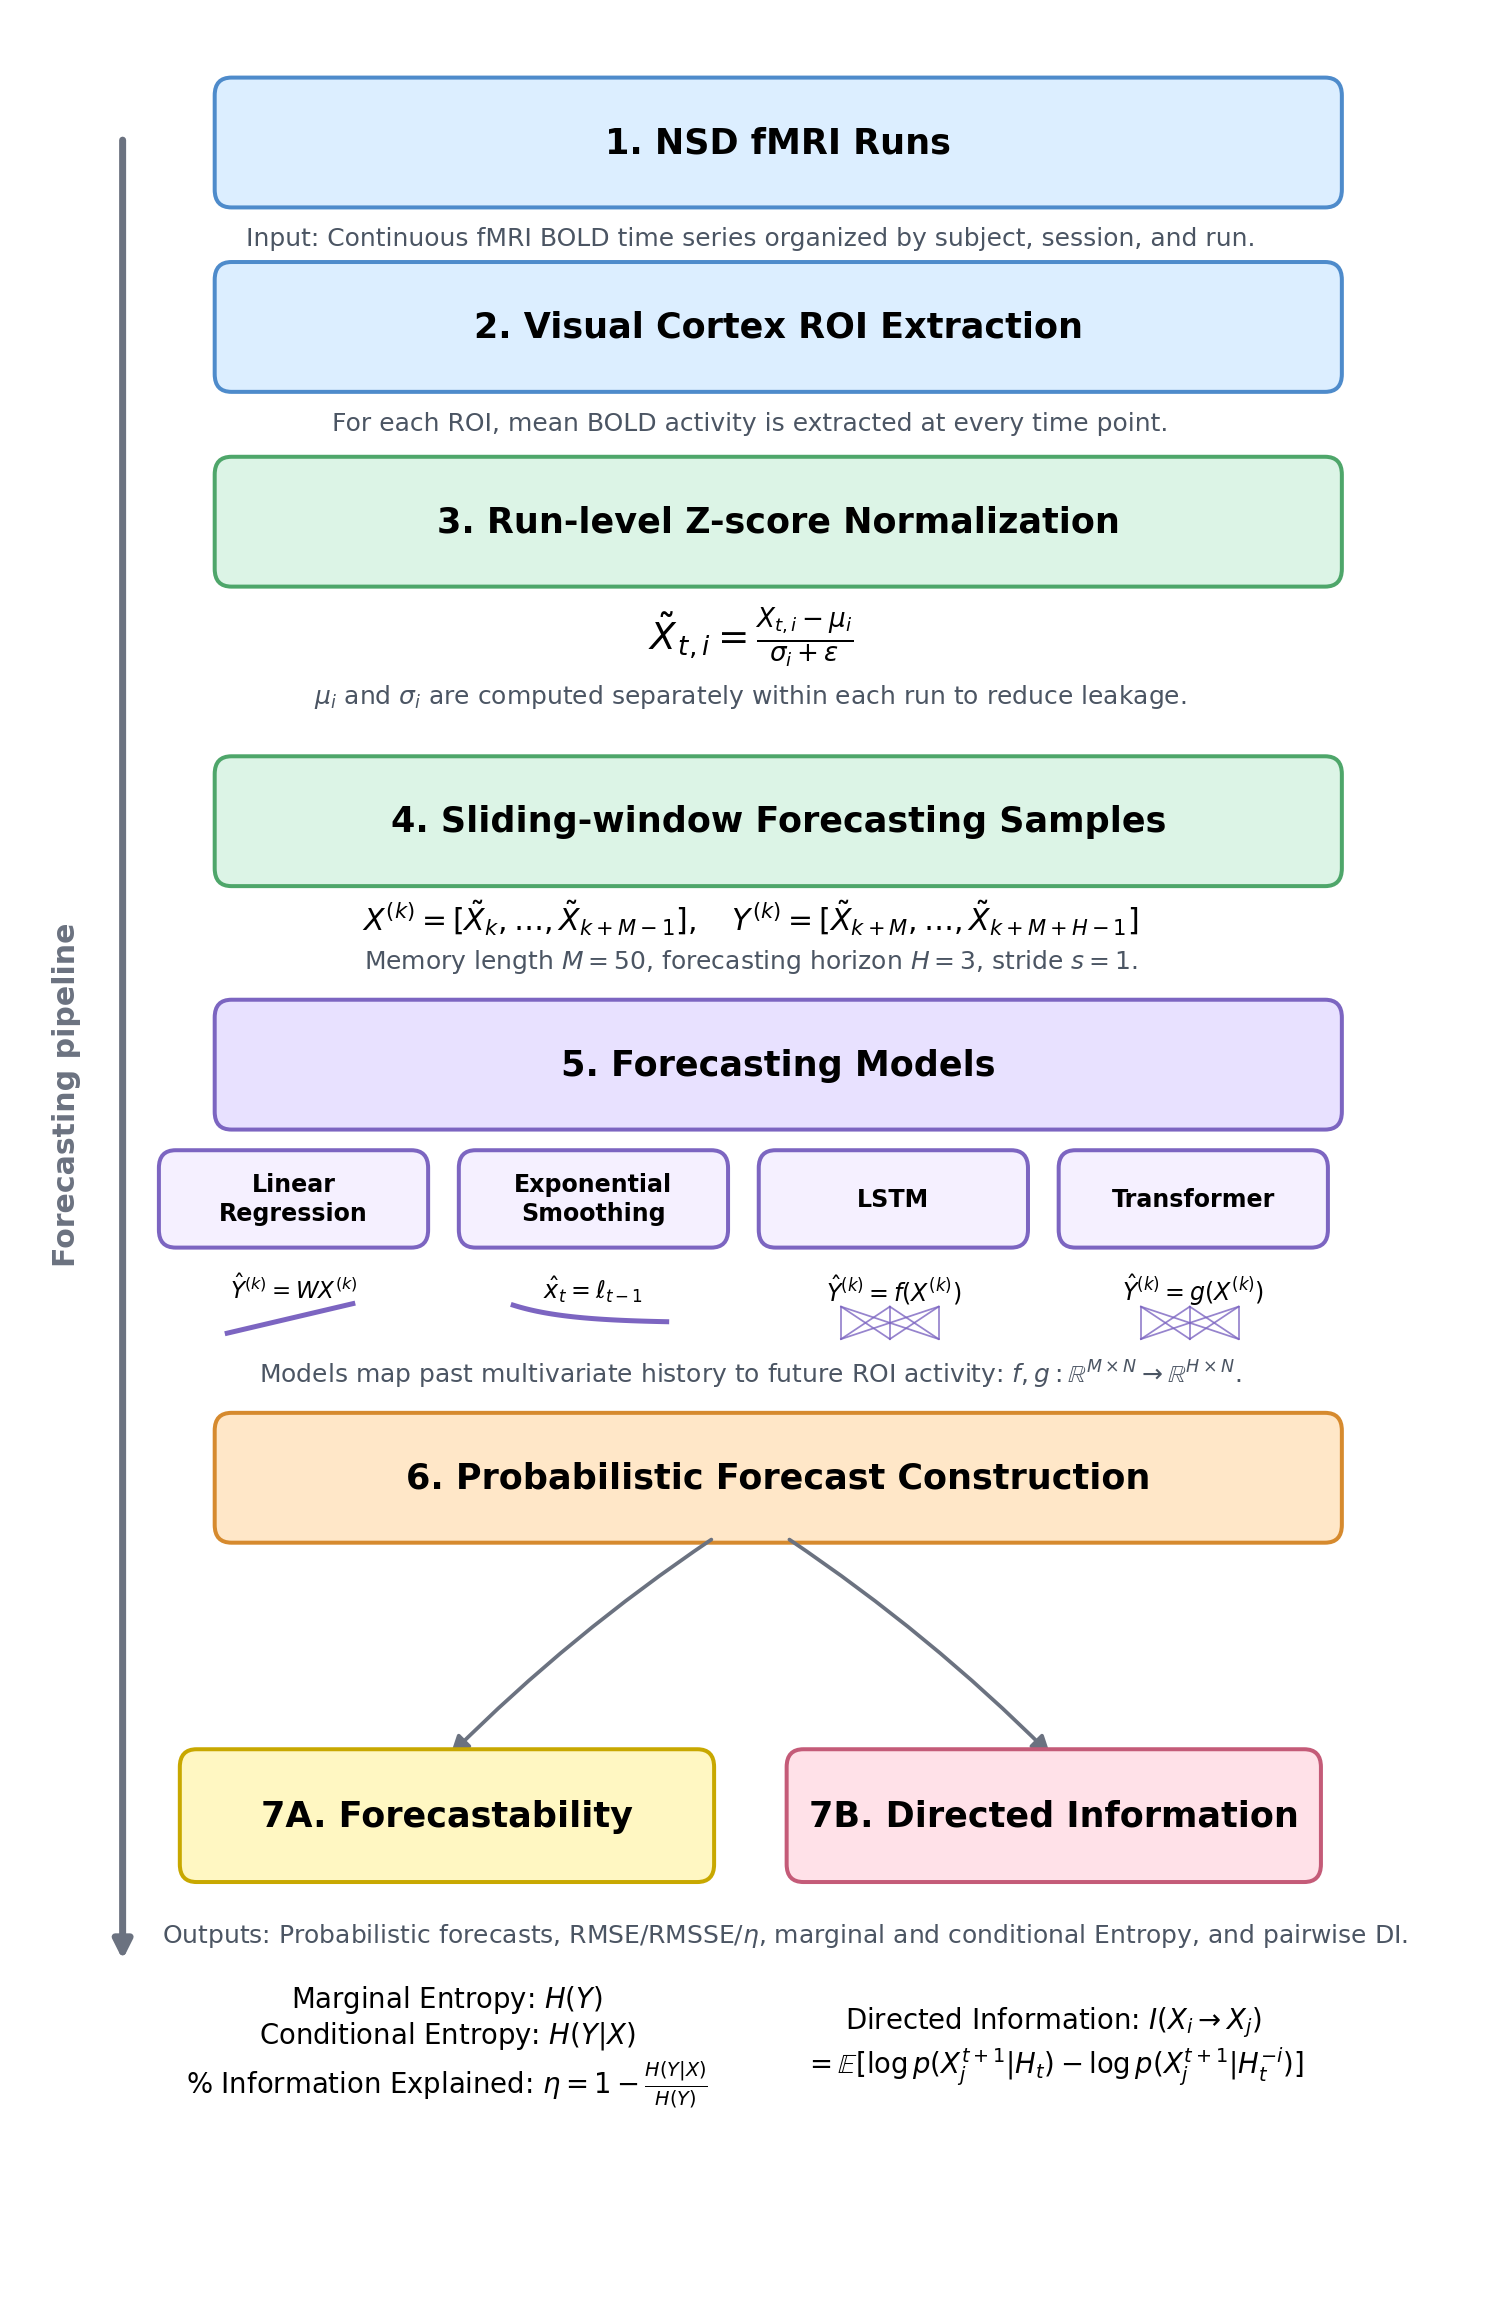

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path
import numpy as np

OUT = Path("saves") / "figures"
OUT.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10.5, 16.5), dpi=180)
ax.set_xlim(0, 10.5)
ax.set_ylim(2.5, 18)
ax.axis("off")

BLUE, BLUE_EDGE = "#DCEEFF", "#4E8BCB"
GREEN, GREEN_EDGE = "#DCF4E6", "#4EA66A"
PURPLE, PURPLE_EDGE = "#E8E1FF", "#7C65C1"
ORANGE, ORANGE_EDGE = "#FFE7C8", "#D68A2E"
YELLOW, YELLOW_EDGE = "#FFF7C2", "#C8A800"
PINK, PINK_EDGE = "#FFE1E8", "#C45B78"
GRAY_TEXT, ARROW = "#4B5563", "#6B7280"

def box(x, y, w, h, text, fc, ec, fs=11., bold=False):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        linewidth=1.6,
        edgecolor=ec,
        facecolor=fc,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fs,
        weight="bold" if bold else "normal",
        linespacing=1.25,
    )
    return patch

def arrow(x1, y1, x2, y2, rad=0.0, lw=1.5):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=lw,
            color=ARROW,
            connectionstyle=f"arc3,rad={rad}",
        )
    )

def center_text(x, y, text, fs=10., color=GRAY_TEXT, style="normal"):
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=fs,
        color=color,
        style=style,
        linespacing=1.25,
    )

# Title
#ax.text(
#    5.25, 18.55,
#    "Probabilistic fMRI Forecasting Pipeline",
#    ha="center",
#    va="center",
#    fontsize=18,
#    weight="bold",
#)

#center_text(
#    5.25, 18.15,
#    "ROI-level BOLD signals are parsed into forecasting samples and analyzed using probabilistic information measures.",
#    fs=9.5,
#)

# Left-side pipeline arrow
arrow(0.75, 17.20, 0.75, 4.80, lw=2.8)
ax.text(
    0.35, 10.7,
    "Forecasting pipeline",
    rotation=90,
    ha="center",
    va="center",
    fontsize=12,
    weight="bold",
    color=ARROW,
)

# 1. Dataset
box(1.45, 16.75, 8.0, 0.80, "1. NSD fMRI Runs", BLUE, BLUE_EDGE, 14, True)
center_text(5.25, 16.50, "Input: Continuous fMRI BOLD time series organized by subject, session, and run.")

# 2. ROI extraction
box(1.45, 15.5, 8.0, 0.80, "2. Visual Cortex ROI Extraction", BLUE, BLUE_EDGE, 14, True)
center_text(5.25, 15.25, "For each ROI, mean BOLD activity is extracted at every time point.")

# 3. Normalization
box(1.45, 14.18, 8.0, 0.80, "3. Run-level Z-score Normalization", GREEN, GREEN_EDGE, 14, True)

ax.text(
    5.25, 13.8,
    r"$\tilde X_{t,i}=\frac{X_{t,i}-\mu_i}{\sigma_i+\epsilon}$",
    ha="center",
    va="center",
    fontsize=15,
)

center_text(
    5.25, 13.4,
    r"$\mu_i$ and $\sigma_i$ are computed separately within each run to reduce leakage.",
)

# 4. Sliding windows
box(1.45, 12.15, 8.0, 0.80, "4. Sliding-window Forecasting Samples", GREEN, GREEN_EDGE, 14, True)

ax.text(
    5.25, 11.90,
    r"$X^{(k)}=[\tilde{X}_k,\ldots,\tilde{X}_{k+M-1}], \quad "
    r"Y^{(k)}=[\tilde{X}_{k+M},\ldots,\tilde{X}_{k+M+H-1}]$",
    ha="center",
    va="center",
    fontsize=12,
)

center_text(
    5.25,
    11.60,
    r"Memory length $M=50$, forecasting horizon $H=3$, stride $s=1$.",
)

# 5. Forecasting models
box(1.45, 10.50, 8.0, 0.80, "5. Forecasting Models", PURPLE, PURPLE_EDGE, 14, True)

model_y = 9.70
panel_w = 1.85
panel_h = 0.58
x_positions = [1.05, 3.20, 5.35, 7.50]

box(x_positions[0], model_y, panel_w, panel_h, "Linear\nRegression", "#F5F0FF", PURPLE_EDGE, 9.5, True)
ax.text(x_positions[0] + panel_w / 2, model_y - 0.32, r"$\hat{Y}^{(k)}=WX^{(k)}$", ha="center", va="center", fontsize=9.2)
ax.plot([x_positions[0] + 0.45, x_positions[0] + 1.35], [model_y - 0.62, model_y - 0.42], lw=2, color=PURPLE_EDGE)

box(x_positions[1], model_y, panel_w, panel_h, "Exponential\nSmoothing", "#F5F0FF", PURPLE_EDGE, 9.5, True)
ax.text(x_positions[1] + panel_w / 2, model_y - 0.32, r"$\hat x_{t}=\ell_{t-1}$", ha="center", va="center", fontsize=9.5)
xs = np.linspace(x_positions[1] + 0.35, x_positions[1] + 1.45, 60)
ys = model_y - 0.55 + 0.12 * np.exp(-2.5 * (xs - xs.min()))
ax.plot(xs, ys, lw=2, color=PURPLE_EDGE)

box(x_positions[2], model_y, panel_w, panel_h, "LSTM", "#F5F0FF", PURPLE_EDGE, 9.5, True)
ax.text(x_positions[2] + panel_w / 2, model_y - 0.32, r"$\hat{Y}^{(k)}=f(X^{(k)})$", ha="center", va="center", fontsize=9.5)
theta = np.linspace(0, 2 * np.pi, 100)
#ax.plot(
#    x_positions[2] + panel_w / 2 + 0.23 * np.cos(theta),
#    model_y - 0.55 + 0.11 * np.sin(theta),
#    lw=1.7,
#    color=PURPLE_EDGE,
#)
for a in [0.55, 0.9, 1.25]:
    for b in [0.55, 0.9, 1.25]:
        ax.plot(
            [x_positions[2] + a, x_positions[2] + b],
            [model_y - 0.66, model_y - 0.44],
            lw=0.7,
            color=PURPLE_EDGE,
            alpha=0.8,
        )

box(x_positions[3], model_y, panel_w, panel_h, "Transformer", "#F5F0FF", PURPLE_EDGE, 9.5, True)
ax.text(x_positions[3] + panel_w / 2, model_y - 0.32, r"$\hat{Y}^{(k)}=g(X^{(k)})$", ha="center", va="center", fontsize=9.5)

for a in [0.55, 0.9, 1.25]:
    for b in [0.55, 0.9, 1.25]:
        ax.plot(
            [x_positions[3] + a, x_positions[3] + b],
            [model_y - 0.66, model_y - 0.44],
            lw=0.7,
            color=PURPLE_EDGE,
            alpha=0.8,
        )

center_text(
    5.25,
    8.80,
    r"Models map past multivariate history to future ROI activity: "
    r"$f,g:\mathbb{R}^{M\times N}\rightarrow\mathbb{R}^{H\times N}$.",
    fs=10.,
)

# 6. Probabilistic forecast construction
box(1.45, 7.70, 8.0, 0.80, "6. Probabilistic Forecast Construction", ORANGE, ORANGE_EDGE, 14, True)

# Split arrows from 6 to 7A and 7B
arrow(5.00, 7.70, 3.075, 6.20, rad=0.05)
arrow(5.50, 7.70, 7.425, 6.20, rad=-0.05)

# 7. Branching analysis blocks
box(1.20, 5.40, 3.75, 0.82, "7A. Forecastability", YELLOW, YELLOW_EDGE, 14, True)

ax.text(
    3.075,
    4.25,
    r"Marginal Entropy: $H(Y)$" "\n"
    r"Conditional Entropy: $H(Y|X)$" "\n"
    r"% Information Explained: $\eta=1-\frac{H(Y|X)}{H(Y)}$",
    ha="center",
    va="center",
    fontsize=11.0,
)

box(5.55, 5.40, 3.75, 0.82, "7B. Directed Information", PINK, PINK_EDGE, 14, True)

ax.text(
    7.425,
    4.25,
    r"Directed Information: $I(X_i\rightarrow X_j)$" "\n"
    r"$=\mathbb{E}[\log p(X_j^{t+1}|H_t)-\log p(X_j^{t+1}|H_t^{-i})]$",
    ha="center",
    va="center",
    fontsize=11.0,
)

center_text(
    5.5,
    5.00,
    r"Outputs: Probabilistic forecasts, RMSE/RMSSE/$\eta$, marginal and conditional Entropy, and pairwise DI.",
    fs=10.0,
)

#ax.text(
#    5.25,
#    2.0,
#    "Note: directed-information analysis is not interpreted for exponential smoothing because it models each ROI independently.",
#    ha="center",
#    va="center",
#    fontsize=10.,
#    color="#6B7280",
#    style="italic",
#)

# Save safely. Avoid bbox_inches='tight' because it caused your PIL/idat save issue.
fig.savefig(OUT / "fmri_pipeline_vertical_clean_v5.png", dpi=250)
fig.savefig(OUT / "fmri_pipeline_vertical_clean_v5.svg")

plt.show()